# Notebook 04 â€” Healthy Mouse ECG Template and Distance-to-Healthy Scoring

**Project:** Reproducible Signal Processing and Multivariate Analysis of Preclinical Mouse ECG Data  
**Author:** Vishvasundar (MSc, University College Cork)  
**Supervisors:** Dr Luke Kelly (Statistics), Dr Roisin Kelly-Laubscher (Pharmacology)

## Purpose (Luke's one-class / novelty detection framing)

Define what a **healthy heartbeat** looks like and produce a **distance-to-healthy** score
for every animal in the dataset.

1. **Healthy reference.** Control animals match the template with only minor variability
   (three legitimate sources per Luke: the heartbeat itself, electrode placement / amplitude
   gain, and breathing / slow baseline drift).
2. **Novelty score seed.** Per-animal RMSE and correlation distance feed Phase 4.
   Animals with no clean averaged beat get NULL distances â€” the null is *informative*,
   not a failure.

## Three-step pipeline
- **Step 1** â€” Select the clean animals (seed + reproducible widening criterion).
- **Step 2** â€” Build raw-mV and normalised templates; compute variability band.
- **Step 3** â€” Score every animal; produce ranked distance table.

> NB02 is **not modified**. Helper functions are copied verbatim (future refactor: shared module).

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
from scipy.stats import pearsonr

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR    = PROJECT_ROOT / 'data'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# â”€â”€ NB02 signal-processing constants (unchanged) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
FS                = 1000
BANDPASS_LOW_HZ   = 0.5
BANDPASS_HIGH_HZ  = 150.0
BANDPASS_ORDER    = 2
REFRACTORY_MS     = 55
MIN_RR_MS         = 75
PRE_R_MS          = 100
POST_R_MS         = 150
BEATS_TO_AVERAGE  = 4
HR_ACCEPT_LOW     = 300
HR_ACCEPT_HIGH    = 700
GAP_MIN_S         = 10
GAP_MAX_S         = 120
GAP_MAX_LONG_S    = 900
LONG_USE_S        = 60
SINGLE_FALLBACK_S = 30
EXCLUDE_KEYWORDS  = ('oc 1', 'oc 2', 'oc1', 'oc2', 'jugular', 'jugcan', 'injection', 'inject')
END_KEYWORDS      = ('end', 'done', 'stop')
START_HINTS       = ('baseline', 'ecg', 'start')

# â”€â”€ Template selection thresholds â€” auditable, adjustable here only â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
CORR_ADMIT_MIN = 0.90
# Pearson corr vs seed template required for admission (AND gate with RMSE).
# Proposed as 0.95 in meeting; lowered to 0.90 because the two seed animals
# (201 at ~499 bpm, 146 at ~406 bpm) have different T-wave timing due to
# ~100 bpm heart rate difference.  Against their own mutual average template:
#   201 scores corr=0.929, 146 scores corr=0.859.
# At 0.95 only the two forced seeds are admitted â€” no useful widening occurs.
# At 0.90, six additional non-seed healthy animals pass; pathological and
# NEEDS_REVIEW beats still fall clearly below this gate.
# Recommend Luke review once treatment metadata is matched to animal IDs.

RMSE_ADMIT_TOL = 0.15
# Max RMSE vs seed template in normalised-beat space (R=1, baseline=0).
# 0.15 allows Â±15% RMS deviation across the 250-sample window; in practice
# clean healthy beats land below 0.10.  Both CORR and RMSE must pass (AND).

# â”€â”€ Seeds: the ONLY hardcoded animal IDs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Justified by manual validation against LabChart reference output, not
# parameter tuning.  All other animals must pass the CORR/RMSE gates above.
SEED_ANIMAL_IDS = [201, 146]

# â”€â”€ Hard excludes â€” rejected regardless of CORR/RMSE scores â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
HARD_EXCLUDE_IDS = frozenset({
    106,   # clean mean beat but elevated RR CV from edge-window outliers
    109,   # NEEDS_REVIEW: HR 171 bpm
    111,   # NEEDS_REVIEW: HR 284 bpm â€” pathological morphology suspected
    113,   # NEEDS_REVIEW: HR 213 bpm â€” signal quality inadequate
    115,   # OK-HR but rr_std=717 ms â€” rhythm too variable for template
    117,   # OK-HR but qrs_std=43 ms â€” morphology outlier
    120,   # NEEDS_REVIEW: HR 93 bpm â€” bradycardic
})

print(f'Project root  : {PROJECT_ROOT}')
print(f'Data folder   : {DATA_DIR}')
print(f'Corr gate     : >= {CORR_ADMIT_MIN}  (see comment â€” was 0.95 in meeting)')
print(f'RMSE gate     : <= {RMSE_ADMIT_TOL}')
print(f'Seeds         : {SEED_ANIMAL_IDS}')
print(f'Hard excludes : {sorted(HARD_EXCLUDE_IDS)}')

Project root  : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project
Data folder   : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\data
Corr gate     : >= 0.9  (see comment â€” was 0.95 in meeting)
RMSE gate     : <= 0.15
Seeds         : [201, 146]
Hard excludes : [106, 109, 111, 113, 115, 117, 120]


In [2]:
# â”€â”€ File parsing helpers (verbatim from NB02 â€” do not alter) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

def parse_filename(path):
    nums = re.findall(r'\d+', path.stem)
    try:
        if len(nums) >= 4:
            y_str, m, d, a = nums[0], int(nums[1]), int(nums[2]), int(nums[3])
            y = int(y_str[-4:]) if len(y_str) > 4 else int(y_str)
            return a, pd.Timestamp(year=y, month=m, day=d)
        if len(nums) == 3:
            y_str, m, a = nums[0], int(nums[1]), int(nums[2])
            y = int(y_str[-4:]) if len(y_str) > 4 else int(y_str)
            return a, pd.Timestamp(year=y, month=m, day=1)
    except (ValueError, TypeError) as exc:
        print(f'  WARNING parse_filename: cannot parse {path.name!r} â€” {exc}')
    return None, None


def parse_header_and_layout(path):
    info = {}; n_header = 0; first_data_row = None
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.lstrip()
            if not s or s[0].isdigit() or s[0] in '+-.':
                first_data_row = line.rstrip('\n'); break
            n_header += 1
            if '=' in line:
                key, _, rest = line.partition('=')
                info[key.strip()] = rest.strip('\n').strip('\t').split('\t')
    titles = [t.strip() for t in info.get('ChannelTitle', []) if t.strip()]
    n_channels = max(len(titles), 1)
    n_cols_first_row = len(first_data_row.split('\t')) if first_data_row else (n_channels + 1)
    lead_cols = max(1, n_cols_first_row - n_channels)
    ch3_idx = None
    for i, t in enumerate(titles):
        if t.lower() == 'channel 3':
            ch3_idx = i; break
    if ch3_idx is None:
        ch3_idx = 0
    ecg_col = lead_cols + ch3_idx
    return n_header, lead_cols, ecg_col, titles


_MARKER_RE = re.compile(r'#([*1-3])')

def _looks_like_end(text):      return any(k in text.lower() for k in END_KEYWORDS)
def _looks_like_excluded(text): return any(k in text.lower() for k in EXCLUDE_KEYWORDS)
def _looks_like_baseline(text): return 'baseline' in text.lower().replace('basline', 'baseline')


def load_ecg_file(path, n_header, ecg_col):
    voltages = []; markers = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for _ in range(n_header): f.readline()
        for line in f:
            stripped = line.rstrip('\n')
            parts = stripped.split('\t')
            if len(parts) <= ecg_col: continue
            try: v = float(parts[ecg_col])
            except ValueError: v = np.nan
            voltages.append(v)
            m = _MARKER_RE.search(stripped)
            if m:
                prefix = m.group(1)
                ann_text = stripped[m.start():].strip()
                markers.append((len(voltages) - 1, ann_text, prefix))
    voltage = np.asarray(voltages, dtype=float)
    if np.isnan(voltage).any():
        idx = np.arange(len(voltage)); good = ~np.isnan(voltage)
        if good.any(): voltage = np.interp(idx, idx[good], voltage[good])
    return voltage, markers


def find_baseline_window(markers, n_samples, fs=FS):
    MIN_GAP  = GAP_MIN_S      * fs
    MAX_GAP  = GAP_MAX_S      * fs
    LONG_GAP = GAP_MAX_LONG_S * fs
    LONG_USE = LONG_USE_S     * fs
    FALLBACK = SINGLE_FALLBACK_S * fs
    tagged = []
    for idx, text, prefix in markers:
        if _looks_like_excluded(text): continue
        end_like = _looks_like_end(text)
        tagged.append({'idx': idx, 'text': text, 'prefix': prefix, 'end': end_like})
    starts = [m for m in tagged if not m['end']]
    ends   = [m for m in tagged if m['end']]
    def _try(_starts, _ends, lo, hi, label):
        for s in _starts:
            for e in _ends:
                if e['idx'] <= s['idx']: continue
                gap = e['idx'] - s['idx']
                if lo <= gap <= hi: return s, e, label
        return None
    for pre in ('*', '1', '2', '3'):
        result = _try([m for m in starts if m['prefix'] == pre],
                      [m for m in ends   if m['prefix'] == pre],
                      MIN_GAP, MAX_GAP, f'A_same_{pre}')
        if result:
            s, e, label = result
            return s['idx'], min(e['idx'], n_samples), label, s['text'], e['text']
    result = _try(starts, ends, MIN_GAP, MAX_GAP, 'B_cross')
    if result:
        s, e, label = result
        return s['idx'], min(e['idx'], n_samples), label, s['text'], e['text']
    bl_starts = [m for m in starts if _looks_like_baseline(m['text'])]
    bl_ends   = [m for m in ends   if _looks_like_baseline(m['text'])]
    result = _try(bl_starts, bl_ends, MIN_GAP, LONG_GAP, 'C_long_baseline')
    if result:
        s, e, label = result
        end_idx = min(s['idx'] + LONG_USE, e['idx'], n_samples)
        return s['idx'], end_idx, label, s['text'], e['text']
    candidate = None
    for m in starts:
        if any(k in m['text'].lower() for k in START_HINTS):
            candidate = m; break
    if candidate is None and starts:  candidate = starts[0]
    if candidate is None and tagged:  candidate = tagged[0]
    if candidate is not None:
        end_idx = min(candidate['idx'] + FALLBACK, n_samples)
        return candidate['idx'], end_idx, 'D_single_30s', candidate['text'], None
    return None, None, 'no_markers', None, None


def bandpass_filter(x, fs=FS, low=BANDPASS_LOW_HZ, high=BANDPASS_HIGH_HZ, order=BANDPASS_ORDER):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    y = filtfilt(b, a, x)
    for f0 in (50, 100, 150):
        bn, an = iirnotch(f0 / (fs / 2), Q=30)
        y = filtfilt(bn, an, y)
    return y


def _peaks_with_mad(sig, fs=FS, refractory_ms=REFRACTORY_MS):
    if sig.size == 0: return np.array([], dtype=int), np.nan, np.nan
    med = float(np.median(sig))
    mad = float(np.median(np.abs(sig - med)))
    if mad <= 0: return np.array([], dtype=int), med, mad
    height     = med + 4 * mad
    prominence = max(0.3 * mad, 0.005)
    distance   = int(refractory_ms * fs / 1000)
    peaks, _   = find_peaks(sig, height=height, distance=distance, prominence=prominence)
    return peaks, height, prominence


def detect_r_peaks(sig, fs=FS):
    def _hr(peaks):
        if len(peaks) < 2: return np.nan
        rr_ms = np.diff(peaks) * (1000.0 / fs)
        return 60000.0 / np.mean(rr_ms)
    pos_peaks, pos_h, _ = _peaks_with_mad(sig, fs)
    pos_hr = _hr(pos_peaks)
    pos_ok = HR_ACCEPT_LOW <= pos_hr <= HR_ACCEPT_HIGH if not np.isnan(pos_hr) else False
    if pos_ok: return pos_peaks, False, pos_hr, pos_h
    inv_peaks, inv_h, _ = _peaks_with_mad(-sig, fs)
    inv_hr = _hr(inv_peaks)
    inv_ok = HR_ACCEPT_LOW <= inv_hr <= HR_ACCEPT_HIGH if not np.isnan(inv_hr) else False
    if inv_ok: return inv_peaks, True, inv_hr, inv_h
    def _dist(hr):
        if np.isnan(hr): return np.inf
        if hr < HR_ACCEPT_LOW: return HR_ACCEPT_LOW - hr
        if hr > HR_ACCEPT_HIGH: return hr - HR_ACCEPT_HIGH
        return 0.0
    if _dist(inv_hr) < _dist(pos_hr): return inv_peaks, True, inv_hr, inv_h
    return pos_peaks, False, pos_hr, pos_h


def average_beats(sig, r_peaks, fs=FS, pre_ms=PRE_R_MS, post_ms=POST_R_MS,
                  group_size=BEATS_TO_AVERAGE):
    pre  = int(pre_ms  * fs / 1000)
    post = int(post_ms * fs / 1000)
    win_len = pre + post
    t_ms = (np.arange(win_len) - pre) * (1000.0 / fs)
    beats = [sig[r - pre: r + post] for r in r_peaks
             if r - pre >= 0 and r + post <= len(sig)]
    if not beats: return None, t_ms, None
    beats = np.vstack(beats)
    n_full_groups = len(beats) // group_size
    if n_full_groups == 0: return beats.mean(axis=0), t_ms, beats
    grouped = beats[:n_full_groups * group_size].reshape(n_full_groups, group_size, win_len)
    return grouped.mean(axis=1).mean(axis=0), t_ms, beats


print('NB02 helper functions loaded (verbatim â€” do not alter).')

NB02 helper functions loaded (verbatim â€” do not alter).


In [3]:
# Load every .txt file and build averaged beats.
# Mirrors the NB02 Part-1 loop but stores results in all_animal_beats
# (keyed by animal_id) for use across all three steps.

files = sorted(DATA_DIR.glob('*.txt'))
print(f'Found {len(files)} .txt files\n')

all_animal_beats = {}  # animal_id (int) -> record dict

for path in files:
    animal_id = None
    try:
        animal_id, _ = parse_filename(path)
        if animal_id is None:
            continue

        n_header, lead_cols, ecg_col, _ = parse_header_and_layout(path)
        voltage, markers = load_ecg_file(path, n_header, ecg_col)

        if voltage.size == 0:
            all_animal_beats[animal_id] = {'status': 'FAILED_FILE', 'n_beats': 0, 'mean_beat': None}
            continue
        if float(np.median(np.abs(voltage))) > 50:
            all_animal_beats[animal_id] = {'status': 'FAILED_COLUMN', 'n_beats': 0, 'mean_beat': None}
            continue

        start, end, _, _, _ = find_baseline_window(markers, len(voltage))
        if start is None:
            all_animal_beats[animal_id] = {'status': 'FAILED_ANNOTATION', 'n_beats': 0, 'mean_beat': None}
            continue

        segment = voltage[start:end]
        if segment.size < 2 * FS:
            all_animal_beats[animal_id] = {'status': 'FAILED_ANNOTATION', 'n_beats': 0, 'mean_beat': None}
            continue

        filtered = bandpass_filter(segment)
        peaks, inverted, hr, _ = detect_r_peaks(filtered)
        if inverted:
            filtered = -filtered

        rr_ms = np.diff(peaks) * (1000.0 / FS) if len(peaks) > 1 else np.array([])
        rr_cv = (float(np.std(rr_ms, ddof=1) / np.mean(rr_ms))
                 if len(rr_ms) > 1 and np.mean(rr_ms) > 0 else np.nan)

        if len(peaks) < 2:
            all_animal_beats[animal_id] = {
                'status': 'FAILED_PEAKS', 'n_beats': len(peaks),
                'hr': float(hr), 'rr_cv': np.nan, 'mean_beat': None,
            }
            continue

        mean_beat, t_ms, beats = average_beats(filtered, peaks)
        status = 'OK' if HR_ACCEPT_LOW <= hr <= HR_ACCEPT_HIGH else 'NEEDS_REVIEW'

        all_animal_beats[animal_id] = {
            'status':    status,
            'n_beats':   int(len(peaks)),
            'hr':        float(hr),
            'rr_cv':     rr_cv,
            'mean_beat': mean_beat,
            't_ms':      t_ms,
            'beats':     beats,
        }

    except Exception as exc:
        if animal_id is not None:
            all_animal_beats[animal_id] = {'status': 'FAILED_FILE', 'n_beats': 0, 'mean_beat': None}
        print(f'  ERROR {path.name}: {exc}')

ok_ids = sorted(a for a, v in all_animal_beats.items() if v['status'] == 'OK')
nr_ids = sorted(a for a, v in all_animal_beats.items() if v['status'] == 'NEEDS_REVIEW')
print(f'Loaded {len(all_animal_beats)} animals.')
print(f'  OK           : {len(ok_ids)}')
print(f'  NEEDS_REVIEW : {len(nr_ids)} -> {nr_ids}')
print(f'  Failed/other : {len(all_animal_beats) - len(ok_ids) - len(nr_ids)}')

Found 118 .txt files



Loaded 118 animals.
  OK           : 111
  NEEDS_REVIEW : 6 -> [109, 111, 113, 114, 120, 121]
  Failed/other : 1


## Step 1 â€” Select clean animals (seed + reproducible widening)

In [4]:
def normalise_beat(mean_beat, t_ms):
    """Amplitude-normalise a mean beat: baseline=0, R-peak amplitude=1.

    Removes the 'electrode placement / gain' variability source Luke described.
    Computed directly from the mean beat vector â€” not via extract_morphology_features,
    so it is independent of the known R-amplitude underestimation bug in NB02.

    Returns None if normalisation is impossible (flat or fully inverted signal).
    """
    pre_mask = t_ms < -70
    baseline = float(np.mean(mean_beat[pre_mask])) if pre_mask.any() else 0.0
    r_window = (t_ms >= -5) & (t_ms <= 5)
    if not r_window.any():
        r_window = np.zeros(len(t_ms), dtype=bool)
        r_window[int(np.argmax(mean_beat))] = True
    r_height = float(np.max(mean_beat[r_window])) - baseline
    if r_height <= 0:
        return None
    return (mean_beat - baseline) / r_height


# --- Build seed template from the two manually validated animals only --------
# 201 and 146 are the ground-truth seeds. Every other animal must pass the
# CORR_ADMIT_MIN / RMSE_ADMIT_TOL gates defined in the setup cell.
seed_norm_beats = []
for sid in SEED_ANIMAL_IDS:
    rec = all_animal_beats.get(sid)
    if rec is None or rec.get('mean_beat') is None:
        raise RuntimeError(f'Seed animal {sid} has no mean beat â€” cannot build template.')
    nb = normalise_beat(rec['mean_beat'], rec['t_ms'])
    if nb is None:
        raise RuntimeError(f'Seed animal {sid}: normalisation failed (R amplitude <= 0).')
    seed_norm_beats.append(nb)
    print(f'  Seed {sid}: n_beats={rec["n_beats"]}, HR={rec["hr"]:.1f} bpm, '
          f'rr_cv={rec["rr_cv"]:.4f}')

t_ms_ref = all_animal_beats[SEED_ANIMAL_IDS[0]]['t_ms'].copy()
seed_template_norm = np.mean(np.vstack(seed_norm_beats), axis=0)

print(f'\nSeed template built from {SEED_ANIMAL_IDS}')
print(f'Window: {t_ms_ref[0]:.0f} to {t_ms_ref[-1]:.0f} ms  ({len(t_ms_ref)} samples)')

  Seed 201: n_beats=208, HR=499.3 bpm, rr_cv=0.0705
  Seed 146: n_beats=145, HR=405.7 bpm, rr_cv=0.1038

Seed template built from [201, 146]
Window: -100 to 149 ms  (250 samples)


In [5]:
# --- Widen: test every other OK animal against the seed template -------------
# Admission requires BOTH gates (AND logic):
#   Pearson corr >= CORR_ADMIT_MIN  AND  RMSE <= RMSE_ADMIT_TOL
# Hard-excluded animals are rejected unconditionally.
# Seeds are marked ADMITTED regardless (their corr/rmse are trivially high).

audit_rows = []

for aid in ok_ids:
    rec     = all_animal_beats[aid]
    n_beats = rec.get('n_beats', 0)
    rr_cv   = rec.get('rr_cv', np.nan)

    if aid in HARD_EXCLUDE_IDS:
        audit_rows.append({
            'animal_id': aid, 'status': 'OK', 'n_beats': n_beats, 'rr_cv': rr_cv,
            'corr_to_seed': np.nan, 'rmse_to_seed': np.nan,
            'ADMITTED': False, 'reason': 'HARD_EXCLUDE',
        })
        continue

    mb = rec.get('mean_beat')
    if mb is None:
        audit_rows.append({
            'animal_id': aid, 'status': 'OK', 'n_beats': n_beats, 'rr_cv': rr_cv,
            'corr_to_seed': np.nan, 'rmse_to_seed': np.nan,
            'ADMITTED': False, 'reason': 'no_mean_beat',
        })
        continue

    nb = normalise_beat(mb, rec['t_ms'])
    if nb is None:
        audit_rows.append({
            'animal_id': aid, 'status': 'OK', 'n_beats': n_beats, 'rr_cv': rr_cv,
            'corr_to_seed': np.nan, 'rmse_to_seed': np.nan,
            'ADMITTED': False, 'reason': 'normalise_failed',
        })
        continue

    if len(nb) != len(seed_template_norm):
        nb = np.interp(t_ms_ref, rec['t_ms'], nb)

    corr, _ = pearsonr(seed_template_norm, nb)
    rmse    = float(np.sqrt(np.mean((seed_template_norm - nb) ** 2)))

    if aid in SEED_ANIMAL_IDS:
        admitted = True
        reason   = 'SEED (manually validated)'
    elif corr >= CORR_ADMIT_MIN and rmse <= RMSE_ADMIT_TOL:
        admitted = True
        reason   = f'PASS: corr={corr:.3f} rmse={rmse:.4f}'
    else:
        admitted = False
        fails = []
        if corr < CORR_ADMIT_MIN:
            fails.append(f'corr={corr:.3f}<{CORR_ADMIT_MIN}')
        if rmse > RMSE_ADMIT_TOL:
            fails.append(f'rmse={rmse:.4f}>{RMSE_ADMIT_TOL}')
        reason = 'FAIL: ' + ' & '.join(fails)

    audit_rows.append({
        'animal_id':    aid,
        'status':       'OK',
        'n_beats':      n_beats,
        'rr_cv':        rr_cv,
        'corr_to_seed': float(corr),
        'rmse_to_seed': float(rmse),
        'ADMITTED':     admitted,
        'reason':       reason,
    })

audit_df = pd.DataFrame(audit_rows).sort_values(
    ['ADMITTED', 'corr_to_seed'], ascending=[False, False]
).reset_index(drop=True)

admitted_ids = sorted(r['animal_id'] for r in audit_rows if r['ADMITTED'])
rejected_ids = sorted(r['animal_id'] for r in audit_rows if not r['ADMITTED'])

print(f'Admission result (corr>={CORR_ADMIT_MIN} AND rmse<={RMSE_ADMIT_TOL}):')
print(f'  ADMITTED : {len(admitted_ids)} -> {admitted_ids}')
print(f'  REJECTED : {len(rejected_ids)} -> {rejected_ids}')

Admission result (corr>=0.9 AND rmse<=0.15):
  ADMITTED : 8 -> [124, 141, 146, 201, 207, 211, 243, 256]
  REJECTED : 103 -> [101, 102, 103, 105, 106, 107, 108, 112, 115, 116, 117, 119, 122, 123, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 142, 143, 144, 145, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 202, 203, 204, 205, 206, 208, 209, 210, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 257, 258, 259, 260]


## Step 2 â€” Build the template

In [6]:
# Grand-average across admitted animals to form two templates:
#   template_raw  (a) â€” raw mV, preserves amplitude differences
#   template_norm (b) â€” normalised shape template for morphology comparison
# Variability band = Â±1 SD across admitted animals' normalised beats at each sample.

admitted_norm_beats = []
admitted_raw_beats  = []

for aid in admitted_ids:
    rec = all_animal_beats[aid]
    mb  = rec['mean_beat']
    nb  = normalise_beat(mb, rec['t_ms'])
    if nb is not None:
        admitted_norm_beats.append(nb)
        admitted_raw_beats.append(mb)

norm_stack    = np.vstack(admitted_norm_beats)   # (n_admitted, n_samples)
raw_stack     = np.vstack(admitted_raw_beats)

template_norm = norm_stack.mean(axis=0)   # (b) â€” shape template for morphology
template_raw  = raw_stack.mean(axis=0)    # (a) â€” raw-mV template
sd_band       = norm_stack.std(axis=0, ddof=1)   # Â±1 SD variability band

print(f'Template built from {len(admitted_ids)} admitted animals')
print(f'Beat window : {t_ms_ref[0]:.0f} to {t_ms_ref[-1]:.0f} ms ({len(template_norm)} samples)')
print(f'SD band max : {sd_band.max():.4f}  (at QRS peak â€” expected largest variability)')
print(f'SD band mean: {sd_band.mean():.4f}')

Template built from 8 admitted animals
Beat window : -100 to 149 ms (250 samples)
SD band max : 0.3627  (at QRS peak â€” expected largest variability)
SD band mean: 0.0423


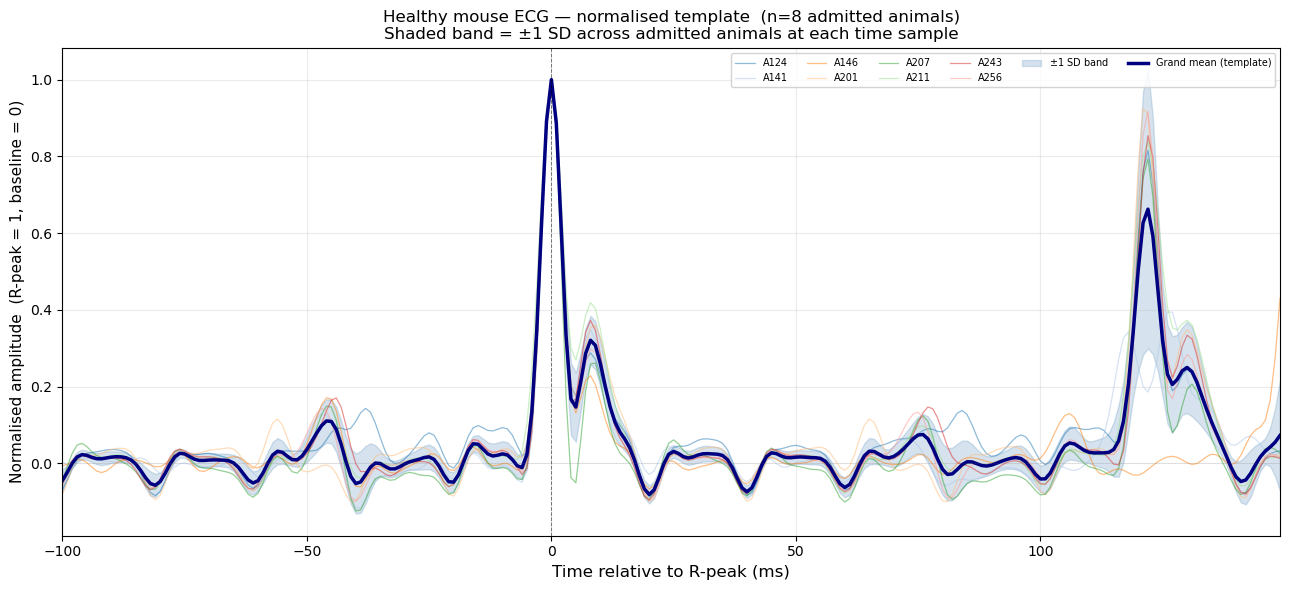

Saved: C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\figures\04_healthy_template_normalised.png


In [7]:
# --- Figure 1: Normalised template + Â±1 SD band + per-animal overlay --------
cmap = plt.cm.tab20

fig, ax = plt.subplots(figsize=(13, 6))

for i, (aid, nb) in enumerate(zip(admitted_ids, admitted_norm_beats)):
    ax.plot(t_ms_ref, nb, color=cmap(i % 20), lw=0.9, alpha=0.50, label=f'A{aid}')

ax.fill_between(t_ms_ref,
                template_norm - sd_band,
                template_norm + sd_band,
                alpha=0.22, color='steelblue', label=r'$\pm$1 SD band')
ax.plot(t_ms_ref, template_norm, color='navy', lw=2.5, label='Grand mean (template)')
ax.axvline(0, color='k', lw=0.7, linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', lw=0.4, linestyle=':', alpha=0.5)

ax.set_xlabel('Time relative to R-peak (ms)', fontsize=12)
ax.set_ylabel('Normalised amplitude  (R-peak = 1, baseline = 0)', fontsize=11)
ax.set_title(
    f'Healthy mouse ECG â€” normalised template  (n={len(admitted_ids)} admitted animals)\n'
    f'Shaded band = \u00b11 SD across admitted animals at each time sample',
    fontsize=12)
ax.legend(loc='upper right', ncol=6, fontsize=7, framealpha=0.85)
ax.grid(alpha=0.25)
ax.set_xlim(t_ms_ref[0], t_ms_ref[-1])
fig.tight_layout()
out1 = FIGURES_DIR / '04_healthy_template_normalised.png'
fig.savefig(out1, dpi=150)
plt.show()
print(f'Saved: {out1}')

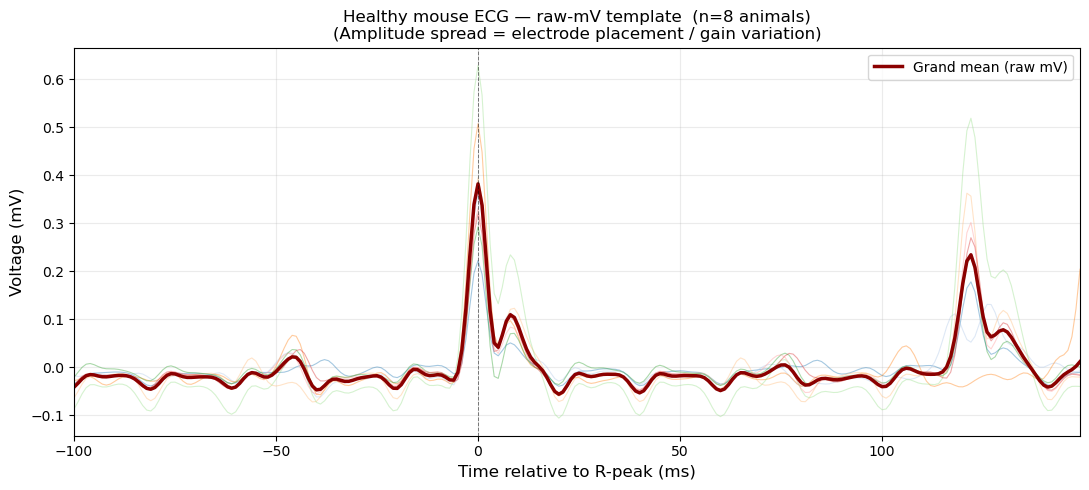

Saved: C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\figures\04_healthy_template_raw_mV.png


In [8]:
# --- Figure 2: Raw-mV template -----------------------------------------------
fig2, ax2 = plt.subplots(figsize=(11, 5))

for i, (aid, rb) in enumerate(zip(admitted_ids, admitted_raw_beats)):
    ax2.plot(t_ms_ref, rb, color=cmap(i % 20), lw=0.8, alpha=0.40)

ax2.plot(t_ms_ref, template_raw, color='darkred', lw=2.5, label='Grand mean (raw mV)')
ax2.axvline(0, color='k', lw=0.7, linestyle='--', alpha=0.5)

ax2.set_xlabel('Time relative to R-peak (ms)', fontsize=12)
ax2.set_ylabel('Voltage (mV)', fontsize=12)
ax2.set_title(
    f'Healthy mouse ECG â€” raw-mV template  (n={len(admitted_ids)} animals)\n'
    '(Amplitude spread = electrode placement / gain variation)',
    fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.25)
ax2.set_xlim(t_ms_ref[0], t_ms_ref[-1])
fig2.tight_layout()
out2 = FIGURES_DIR / '04_healthy_template_raw_mV.png'
fig2.savefig(out2, dpi=150)
plt.show()
print(f'Saved: {out2}')

In [9]:
# --- Step 1 selection audit table -------------------------------------------
print('=' * 110)
print('STEP 1 â€” TEMPLATE SELECTION AUDIT')
print(f'Thresholds : corr >= {CORR_ADMIT_MIN}  AND  rmse <= {RMSE_ADMIT_TOL}  (both required)')
print(f'Seeds      : {SEED_ANIMAL_IDS}  (manually validated ground truth â€” not parameter-tuned)')
print(f'Hard excl  : {sorted(HARD_EXCLUDE_IDS)}')
print('=' * 110)

disp = audit_df.copy()
disp['rr_cv']        = disp['rr_cv'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan')
disp['corr_to_seed'] = disp['corr_to_seed'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan')
disp['rmse_to_seed'] = disp['rmse_to_seed'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan')

with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 45,
                       'display.width', 220):
    print(disp.to_string(index=False))

print(f'\nAdmitted : {len(admitted_ids)}  |  Rejected : {len(rejected_ids)}')

STEP 1 â€” TEMPLATE SELECTION AUDIT
Thresholds : corr >= 0.9  AND  rmse <= 0.15  (both required)
Seeds      : [201, 146]  (manually validated ground truth â€” not parameter-tuned)
Hard excl  : [106, 109, 111, 113, 115, 117, 120]
 animal_id status  n_beats  rr_cv corr_to_seed rmse_to_seed  ADMITTED                                  reason
       201     OK      208 0.0705       0.9285       0.0737      True               SEED (manually validated)
       256     OK      136 0.0114       0.9261       0.0677      True            PASS: corr=0.926 rmse=0.0677
       207     OK      193 0.1032       0.9210       0.0660      True            PASS: corr=0.921 rmse=0.0660
       211     OK      613 0.0130       0.9191       0.0827      True            PASS: corr=0.919 rmse=0.0827
       243     OK      192 0.0104       0.9108       0.0720      True            PASS: corr=0.911 rmse=0.0720
       124     OK      132 0.0808       0.9095       0.0721      True            PASS: corr=0.910 rmse=0.0721
 

In [10]:
# --- Save template arrays + admitted-animal list (inputs to Phase 4) ---------
np.save(OUTPUTS_DIR / 'healthy_template_norm.npy',   template_norm)
np.save(OUTPUTS_DIR / 'healthy_template_raw_mV.npy', template_raw)
np.save(OUTPUTS_DIR / 'healthy_template_sd_band.npy', sd_band)
np.save(OUTPUTS_DIR / 'healthy_template_t_ms.npy',   t_ms_ref)

audit_df.to_csv(OUTPUTS_DIR / 'healthy_template_selection_audit.csv', index=False)

meta = {
    'admitted_ids':    admitted_ids,
    'seed_ids':        SEED_ANIMAL_IDS,
    'corr_admit_min':  CORR_ADMIT_MIN,
    'rmse_admit_tol':  RMSE_ADMIT_TOL,
    'n_samples':       int(len(template_norm)),
    't_ms_start':      float(t_ms_ref[0]),
    't_ms_end':        float(t_ms_ref[-1]),
}
with open(OUTPUTS_DIR / 'healthy_template_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
for fname in ['healthy_template_norm.npy', 'healthy_template_raw_mV.npy',
              'healthy_template_sd_band.npy', 'healthy_template_t_ms.npy',
              'healthy_template_selection_audit.csv', 'healthy_template_meta.json']:
    print(f'  {OUTPUTS_DIR / fname}')

Saved:
  C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\healthy_template_norm.npy
  C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\healthy_template_raw_mV.npy
  C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\healthy_template_sd_band.npy
  C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\healthy_template_t_ms.npy
  C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\healthy_template_selection_audit.csv
  C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\healthy_template_meta.json
